In [12]:
import pandas as pd

def load_data(path: str) -> pd.DataFrame:
    """
    Loads CSV data from the given path.
    """
    df = pd.read_csv(path)
    return df

In [13]:
import pandas as pd
import numpy as np

In [14]:
DATA_PATH = "/content/churn.csv.csv"

df = load_data(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.shape

(7043, 21)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [19]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [20]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df = df.drop_duplicates()

In [23]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')
Numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [24]:
from sklearn.impute import SimpleImputer

def impute_numerical(df, columns):
    imputer = SimpleImputer(strategy="median")
    df[columns] = imputer.fit_transform(df[columns])
    return df

def impute_categorical(df, columns):
    imputer = SimpleImputer(strategy="most_frequent")
    df[columns] = imputer.fit_transform(df[columns])
    return df

In [25]:
df = impute_numerical(df, numerical_cols)
df = impute_categorical(df, categorical_cols)

In [26]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [27]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [28]:
X = df.drop('Churn_1', axis=1)
y = df['Churn_1']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [31]:
import os

processed_path = "../data/processed/churn_clean.csv"
output_dir = os.path.dirname(processed_path)

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

df.to_csv(processed_path, index=False)

**EDA**

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [33]:
df = pd.read_csv("../data/processed/churn_clean.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_1
0,0.0,1.0,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.0,34.0,56.95,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.0,2.0,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.0,45.0,42.30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.0,2.0,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [34]:
churn_counts = df['Churn_1'].value_counts()
churn_percent = df['Churn_1'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percent)

Churn_1
False    5174
True     1869
Name: count, dtype: int64
Churn_1
False    73.463013
True     26.536987
Name: proportion, dtype: float64


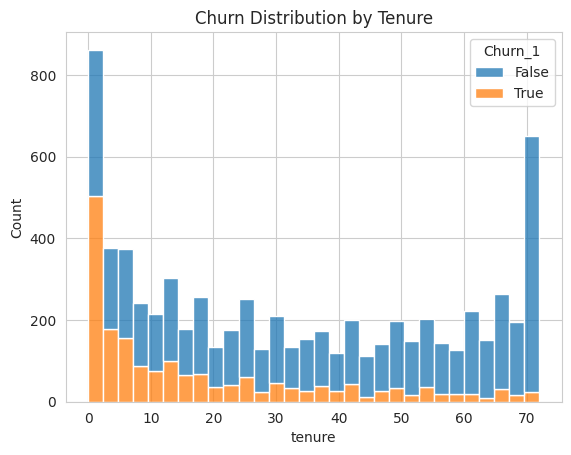

In [35]:
plt.figure()
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn_1",
    bins=30,
    kde=False,
    multiple="stack"
)
plt.title("Churn Distribution by Tenure")
plt.show()

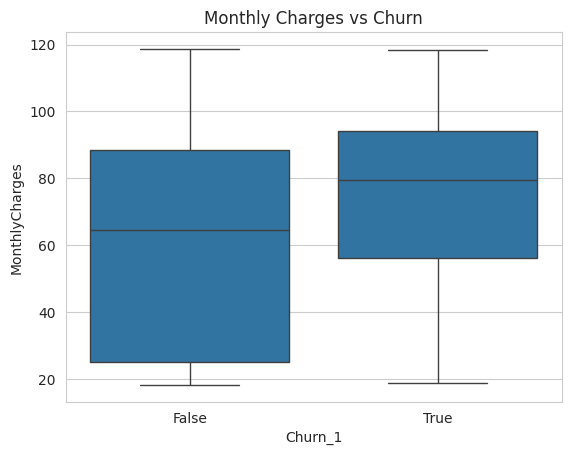

In [36]:
plt.figure()
sns.boxplot(
    data=df,
    x="Churn_1",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Churn")
plt.show()

In [37]:
contract_cols = [col for col in df.columns if "Contract_" in col]

contract_churn = df.groupby("Churn_1")[contract_cols].mean().T
contract_churn

Churn_1,False,True
Contract_One year,0.252609,0.088818
Contract_Two year,0.318322,0.025682


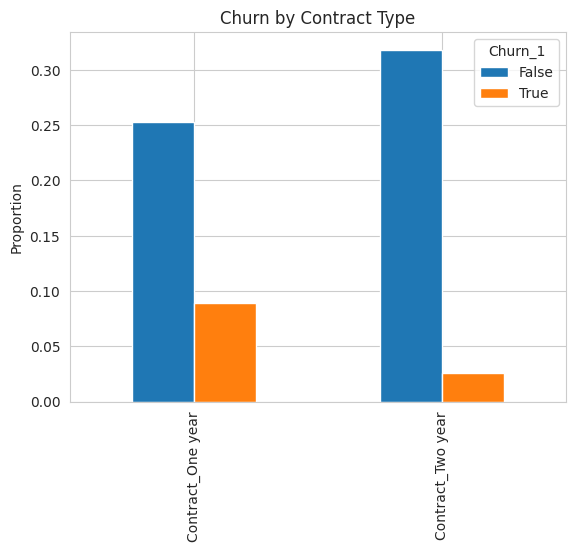

In [38]:
contract_churn.plot(kind="bar")
plt.title("Churn by Contract Type")
plt.ylabel("Proportion")
plt.show()

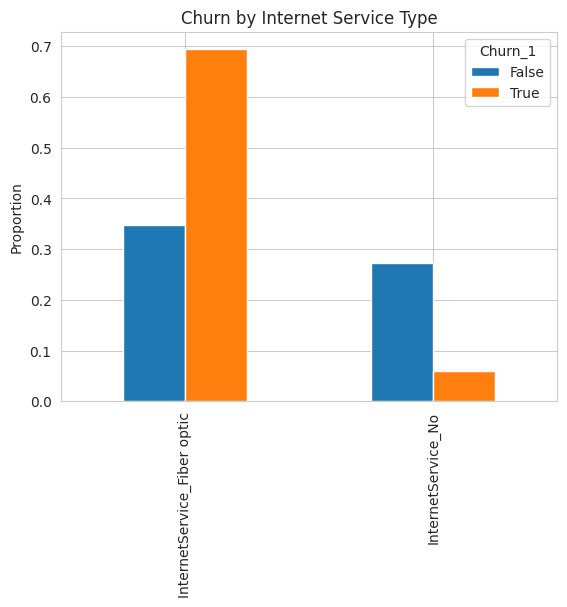

In [39]:
internet_cols = [col for col in df.columns if "InternetService_" in col]

df.groupby("Churn_1")[internet_cols].mean().T.plot(kind="bar")
plt.title("Churn by Internet Service Type")
plt.ylabel("Proportion")
plt.show()

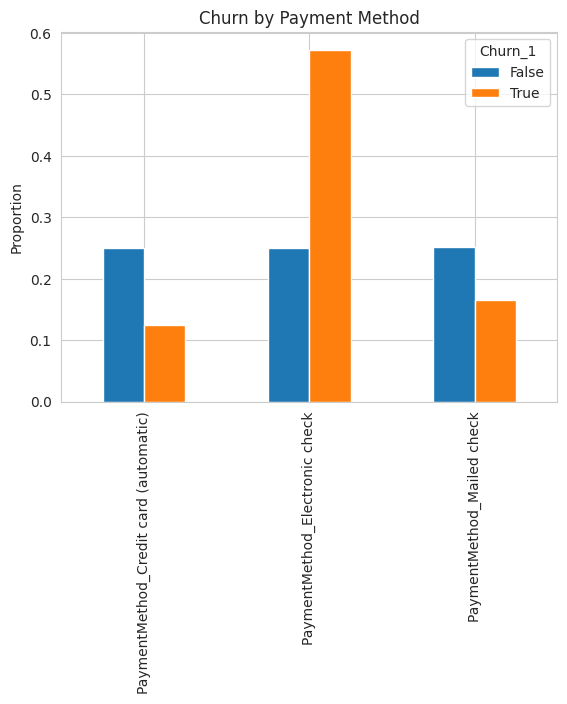

In [40]:
payment_cols = [col for col in df.columns if "PaymentMethod_" in col]

df.groupby("Churn_1")[payment_cols].mean().T.plot(kind="bar")
plt.title("Churn by Payment Method")
plt.ylabel("Proportion")
plt.show()

**Modeling**

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

In [42]:
df = pd.read_csv("../data/processed/churn_clean.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_1
0,0.0,1.0,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.0,34.0,56.95,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.0,2.0,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.0,45.0,42.30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.0,2.0,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [43]:
df.shape

(7043, 13602)

In [44]:
X = df.drop("Churn_1", axis=1)
y = df["Churn_1"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [47]:
y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

roc_auc_lr

np.float64(0.840181869849389)

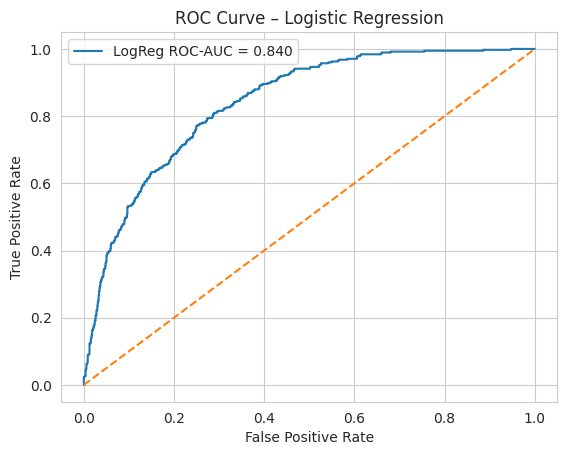

In [48]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg ROC-AUC = {roc_auc_lr:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

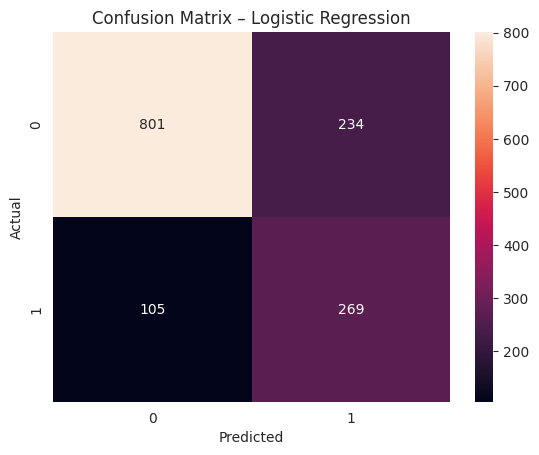

In [49]:
y_pred_lr = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.88      0.77      0.83      1035
        True       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [51]:
feature_importance = pd.Series(
    log_reg.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

feature_importance.head(10)

,0
TotalCharges_1052.35,1.527369
customerID_0607-DAAHE,1.527369
TotalCharges_1099.6,1.504260
customerID_6323-AYBRX,1.504260
TotalCharges_4759.75,1.489972
customerID_3512-IZIKN,1.489972
TotalCharges_5154.6,1.440313
customerID_8631-NBHFZ,1.440313
TotalCharges_20.15,1.394842
TotalCharges_19.9,1.386252


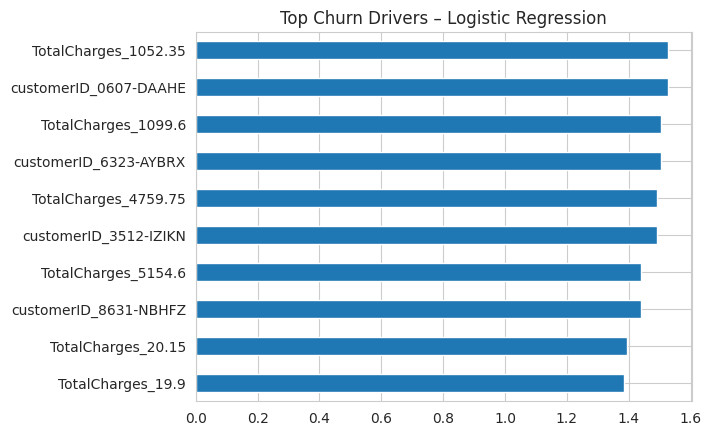

In [52]:
feature_importance.head(10).plot(kind="barh")
plt.title("Top Churn Drivers – Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

In [53]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [54]:
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

roc_auc_rf

np.float64(0.8138223668914207)

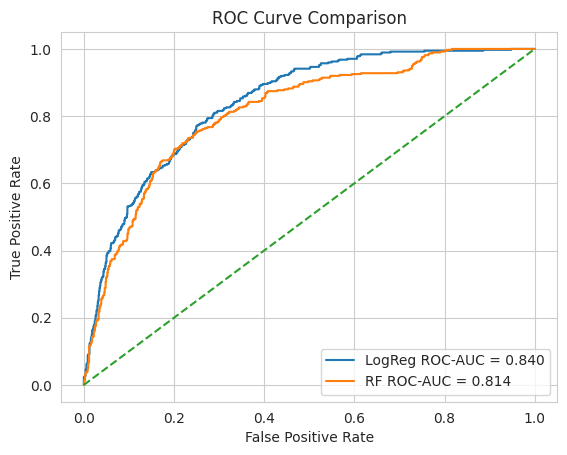

In [55]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg ROC-AUC = {roc_auc_lr:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"RF ROC-AUC = {roc_auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [56]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(10)

,0
tenure,0.063425
Contract_Two year,0.060613
InternetService_Fiber optic,0.055301
StreamingTV_No internet service,0.054608
StreamingMovies_No internet service,0.044897
DeviceProtection_No internet service,0.041332
TechSupport_No internet service,0.040599
OnlineBackup_No internet service,0.038067
PaymentMethod_Electronic check,0.033948
MonthlyCharges,0.028997


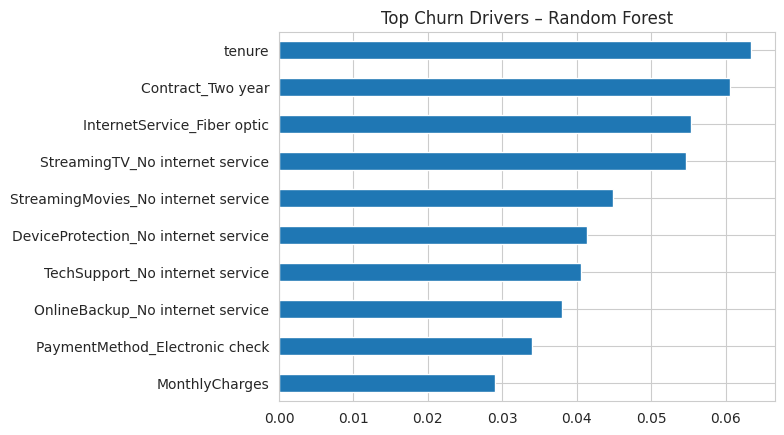

In [57]:
rf_importance.head(10).plot(kind="barh")
plt.title("Top Churn Drivers – Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [58]:
!pip install xgboost

In [59]:
from xgboost import XGBClassifier

In [60]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

In [61]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [62]:
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

roc_auc_xgb

np.float64(0.8400423674080963)

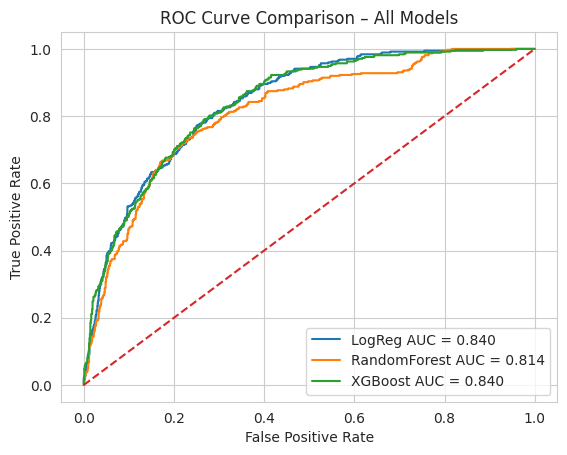

In [63]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc_lr:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest AUC = {roc_auc_rf:.3f}")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – All Models")
plt.legend()
plt.show()

In [64]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(10)

,0
InternetService_Fiber optic,0.194846
Contract_Two year,0.151617
OnlineSecurity_No internet service,0.084420
Contract_One year,0.083783
InternetService_No,0.067693
OnlineBackup_No internet service,0.056277
PaymentMethod_Electronic check,0.042481
tenure,0.035012
StreamingMovies_Yes,0.022150
OnlineSecurity_Yes,0.020011


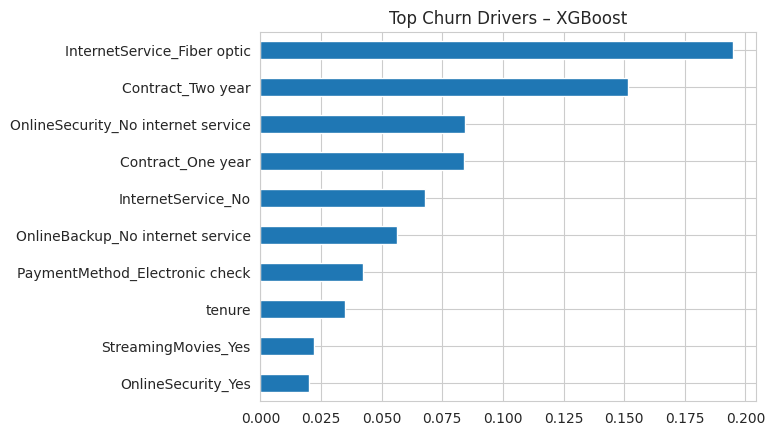

In [65]:
xgb_importance.head(10).plot(kind="barh")
plt.title("Top Churn Drivers – XGBoost")
plt.gca().invert_yaxis()
plt.show()

In [66]:
results = X_test.copy()
results["actual_churn"] = y_test.values
results["predicted_churn_probability"] = y_pred_proba_xgb

results.to_csv("../data/processed/churn_predictions.csv", index=False)

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [68]:
df = pd.read_csv("../data/processed/churn_predictions.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,actual_churn,predicted_churn_probability
0,0.0,72.0,114.05,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.007079
1,1.0,8.0,100.15,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.874627
2,0.0,41.0,78.35,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.063804
3,0.0,18.0,78.20,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.322006
4,0.0,72.0,82.65,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.005003


In [69]:
df.shape

(1409, 13603)

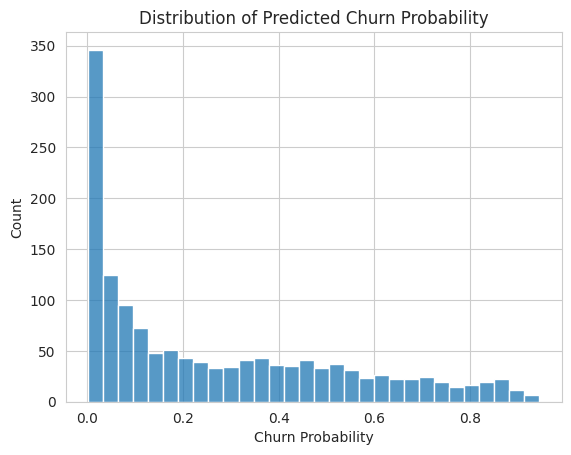

In [70]:
plt.figure()
sns.histplot(df["predicted_churn_probability"], bins=30)
plt.title("Distribution of Predicted Churn Probability")
plt.xlabel("Churn Probability")
plt.show()

In [71]:
risk_threshold = df["predicted_churn_probability"].quantile(0.85)

risk_threshold

np.float64(0.58786472)

In [72]:
df["high_risk"] = (df["predicted_churn_probability"] >= risk_threshold).astype(int)

df["high_risk"].value_counts(normalize=True)

,proportion
high_risk,
0,0.849539
1,0.150461


In [73]:
pd.crosstab(df["high_risk"], df["actual_churn"], normalize="columns")

actual_churn,False,True
high_risk,,
0,0.940097,0.59893
1,0.059903,0.40107


In [74]:
AVG_MONTHLY_REVENUE = 2000
RETENTION_COST = 500
RETENTION_SUCCESS_RATE = 0.30
EXPECTED_MONTHS_RETAINED = 6

In [75]:
revenue_per_customer = AVG_MONTHLY_REVENUE * EXPECTED_MONTHS_RETAINED
revenue_per_customer

12000

In [76]:
high_risk_churners = df[
    (df["high_risk"] == 1) & (df["actual_churn"] == 1)
]

num_targeted = len(high_risk_churners)
num_saved = int(num_targeted * RETENTION_SUCCESS_RATE)

num_targeted, num_saved

(150, 45)

In [77]:
total_revenue_saved = num_saved * revenue_per_customer
total_revenue_saved

540000

In [78]:
total_retention_cost = num_targeted * RETENTION_COST
total_retention_cost

75000

In [79]:
net_impact = total_revenue_saved - total_retention_cost
net_impact

465000

In [80]:
roi = (net_impact / total_retention_cost) * 100
roi

620.0

In [81]:
thresholds = [0.80, 0.85, 0.90]
results = []

for t in thresholds:
    cutoff = df["predicted_churn_probability"].quantile(t)
    subset = df[(df["predicted_churn_probability"] >= cutoff) & (df["actual_churn"] == 1)]

    targeted = len(subset)
    saved = int(targeted * RETENTION_SUCCESS_RATE)
    revenue_saved = saved * revenue_per_customer
    cost = targeted * RETENTION_COST
    net = revenue_saved - cost

    results.append([t, targeted, saved, net])

scenario_df = pd.DataFrame(
    results,
    columns=["Risk Percentile", "Churners Targeted", "Customers Saved", "Net Impact (₹)"]
)

scenario_df

,Risk Percentile,Churners Targeted,Customers Saved,Net Impact (₹)
0,0.80,184,55,568000
1,0.85,150,45,465000
2,0.90,108,32,330000


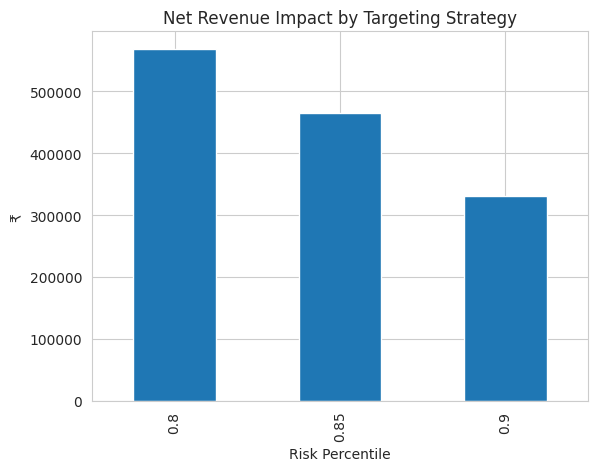

In [82]:
scenario_df.plot(
    x="Risk Percentile",
    y="Net Impact (₹)",
    kind="bar",
    legend=False
)
plt.title("Net Revenue Impact by Targeting Strategy")
plt.ylabel("₹")
plt.show()

In [84]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load the processed data which already contains the 'Churn_1' column
df = pd.read_csv("../data/processed/churn_clean.csv")

X = df.drop("Churn_1", axis=1)
y = df["Churn_1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results["actual_churn"] = y_test.values
results["predicted_churn_probability"] = y_pred_proba

results.to_csv("churn_predictions.csv", index=False)

results.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,actual_churn,predicted_churn_probability
437,0.0,72.0,114.05,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.007079
2280,1.0,8.0,100.15,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.874627
2235,0.0,41.0,78.35,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.063804
4460,0.0,18.0,78.20,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.322006
3761,0.0,72.0,82.65,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.005003


In [85]:
!pip install streamlit pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 96.5 MB/s eta 0:00:00


In [98]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

st.set_page_config(
    page_title="Customer Churn Prediction & Retention Dashboard",
    layout="wide"
)

st.title("📉 Customer Churn Prediction & Retention Dashboard")

st.markdown("""
Interactive dashboard to analyze churn risk, evaluate model performance,
and simulate business impact of retention strategies.
""")

# ----------------------------
# Load Data
# ----------------------------
@st.cache_data
def load_data():
    return pd.read_csv("churn_predictions.csv")

df = load_data()

# ----------------------------
# Sidebar Filters
# ----------------------------
st.sidebar.header("🔎 Filters")

tenure_min = st.sidebar.slider("Minimum Tenure", 0, int(df["tenure"].max()), 0)
charge_min = st.sidebar.slider("Minimum Monthly Charges", 0, int(df["MonthlyCharges"].max()), 0)

filtered_df = df[
    (df["tenure"] >= tenure_min) &
    (df["MonthlyCharges"] >= charge_min)
]

# ----------------------------
# Risk Threshold
# ----------------------------
risk_percentile = st.sidebar.slider(
    "High-Risk Percentile",
    80, 95, 85, step=5
)

threshold = np.percentile(
    filtered_df["predicted_churn_probability"],
    risk_percentile
)

filtered_df["high_risk"] = filtered_df["predicted_churn_probability"] >= threshold

high_risk_df = filtered_df[filtered_df["high_risk"]]
low_risk_df = filtered_df[~filtered_df["high_risk"]]

# ----------------------------
# KPIs
# ----------------------------
st.subheader("📊 Key Metrics")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Customers (Filtered)", len(filtered_df))
col2.metric("High-Risk Customers", len(high_risk_df))
col3.metric("Avg Churn Probability", f"{filtered_df['predicted_churn_probability'].mean():.2f}")
col4.metric("Actual Churn Rate (High Risk)", f"{high_risk_df['actual_churn'].mean():.2%}")

# ----------------------------
# Confusion Matrix
# ----------------------------
st.subheader("📌 Confusion Matrix")

y_true = filtered_df["actual_churn"]
y_pred = (filtered_df["predicted_churn_probability"] >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
st.pyplot(fig)

# ----------------------------
# ROC Curve
# ----------------------------
st.subheader("📈 ROC Curve")

fpr, tpr, _ = roc_curve(filtered_df["actual_churn"], filtered_df["predicted_churn_probability"])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
st.pyplot(fig)

# ----------------------------
# Tenure Segments
# ----------------------------
st.subheader("🧩 Churn by Tenure Segment")

filtered_df["tenure_group"] = pd.cut(
    filtered_df["tenure"],
    bins=[0, 6, 12, 24, 60, 100],
    labels=["0-6", "6-12", "12-24", "24-60", "60+"]
)

tenure_churn = filtered_df.groupby("tenure_group")["actual_churn"].mean()

st.bar_chart(tenure_churn)

# ----------------------------
# Contract-Type Comparison
# ----------------------------
contract_columns = [col for col in filtered_df.columns if "Contract_" in col]

if contract_columns:
    st.subheader("📃 Churn by Contract Type")

    contract_df = pd.DataFrame()

    for col in contract_columns:
        contract_df[col] = [
            filtered_df[filtered_df[col] == 1]["actual_churn"].mean()
        ]

    contract_df = contract_df.T
    contract_df.columns = ["Churn Rate"]

    st.bar_chart(contract_df)

# ----------------------------
# Revenue Simulation
# ----------------------------
st.subheader("💰 Retention Simulation")

AVG_MONTHLY_REVENUE = st.sidebar.number_input("Avg Monthly Revenue (₹)", value=2000)
RETENTION_COST = st.sidebar.number_input("Retention Offer Cost (₹)", value=500)
SUCCESS_RATE = st.sidebar.slider("Retention Success Rate", 0.1, 0.7, 0.3)
EXPECTED_MONTHS = st.sidebar.number_input("Retention Duration (Months)", value=6)

num_targeted = len(high_risk_df[high_risk_df["actual_churn"] == 1])
num_saved = int(num_targeted * SUCCESS_RATE)

revenue_per_customer = AVG_MONTHLY_REVENUE * EXPECTED_MONTHS
total_revenue_saved = num_saved * revenue_per_customer
total_cost = num_targeted * RETENTION_COST
net_profit = total_revenue_saved - total_cost

col1, col2, col3 = st.columns(3)
col1.metric("Churners Targeted", num_targeted)
col2.metric("Revenue Saved (₹)", f"{total_revenue_saved:,.0f}")
col3.metric("Net Profit Impact (₹)", f"{net_profit:,.0f}")

# ----------------------------
# Download Button
# ----------------------------
st.subheader("⬇ Download High-Risk Customers")

st.download_button(
    label="Download High-Risk Segment CSV",
    data=high_risk_df.to_csv(index=False),
    file_name="high_risk_customers.csv",
    mime="text/csv"
)

# ----------------------------
# Top Customers Table
# ----------------------------
st.subheader("🔍 Top High-Risk Customers")

st.dataframe(
    high_risk_df
    .sort_values("predicted_churn_probability", ascending=False)
    .head(20)
)

2026-02-13 13:03:25.769 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.771 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.777 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:03:25.782 No runtime found, using MemoryCacheStorageManager
2026-02-13 13:03:25.796 Thread 'MainThread':

DeltaGenerator()

In [87]:
import os
print(os.listdir())

['.config', 'churn_predictions.csv', 'churn.csv.csv', 'streamlit_app.py', 'sample_data']


In [88]:
from pyngrok import ngrok

!ngrok config add-authtoken 32E7Rn2n9rVdFKD7uV06sYCk3oC_4Frpjnyk6h6ppaW2rSeEZ

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [89]:
!nohup streamlit run streamlit_app.py --server.port 8501 &

nohup: appending output to 'nohup.out'


In [90]:
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://a9ed-136-110-0-174.ngrok-free.app" -> "http://localhost:8501">

In [102]:
!pkill -f streamlit

In [103]:
!streamlit run streamlit_app.py &>/dev/null &

In [104]:
from pyngrok import ngrok

# Kill any existing ngrok processes to free up tunnels
!pkill -f ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://5404-136-110-0-174.ngrok-free.app" -> "http://localhost:8501"
